# Data Preprocessing

In [1]:
# Imports for data processing and visualization
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Custom module imports
from battery_soh_estimator.features.train import (
    dyn_features,  # Feature configuration dyn tests
    ocv_features,  # Feature configuration ocv tests
    target,  # Target variable processing
)
from battery_soh_estimator.features.core import (
    features_func,  # Feature calculation functions
    common_features,  # Features common configuration
)
from battery_soh_estimator.utils.data_loader import (
    load_data_to_dict  # Data loading utilities
)
from battery_soh_estimator.utils.data_process import (
    add_temp_column,
    merge_dicts,
    process_dataframes,
    process_nested_dicts
)
from battery_soh_estimator.model import (
    BatterySoHModel,
)

## Extract Data from the OCV Tests

### Initialization

Load `.xlsx` files using the `load_data_to_dict` function from **Incremental Current OCV tests** for Sample 1 and Sample 2 to a dictionary-based structure, where each key corresponds to a specific test condition (0°C, 25°C, 45°C).

In [2]:
# initial files
ocv_initial = {}

# load initial of Sample 1
ocv_initial.update(
    load_data_to_dict(
        "../data/raw/OCV-SOC/Incremental_Current_OCV/Sample1",
        initial_sp1="Incremental_current_OCV_test_Initial_capacity_SP1.xlsx",
    )
)

# load initial of Sample 2
ocv_initial.update(
    load_data_to_dict(
        "../data/raw/OCV-SOC/Incremental_Current_OCV/Sample2",
        initial_sp2="Incremental_current_OCV_test_Initial_capacity_SP2.xlsx",
    )
)

[Skip] 'Incremental_current_OCV_test_Initial_capacity_SP1.xlsx' already loaded as 'initial_sp1'
[Skip] 'Incremental_current_OCV_test_Initial_capacity_SP2.xlsx' already loaded as 'initial_sp2'


In [3]:
# Sample1
incremental_current_ocv_test_sp1 = load_data_to_dict(
    "../data/raw/OCV-SOC/Incremental_Current_OCV/Sample1",
    temp_0="Incremental_current_OCV_test_SP1-0.xlsx",
    temp_25="Incremental_current_OCV_test_SP1-25.xlsx",
    temp_45="Incremental_current_OCV_test_SP1-45.xlsx",
)

[Skip] 'Incremental_current_OCV_test_SP1-0.xlsx' already loaded as 'temp_0'
[Skip] 'Incremental_current_OCV_test_SP1-25.xlsx' already loaded as 'temp_25'
[Skip] 'Incremental_current_OCV_test_SP1-45.xlsx' already loaded as 'temp_45'


In [4]:
# Sample2
incremental_current_ocv_test_sp2 = load_data_to_dict(
    "../data/raw/OCV-SOC/Incremental_Current_OCV/Sample2",
    temp_0="Incremental_current_OCV_test_SP2-0.xlsx",
    temp_25="Incremental_current_OCV_test_SP2-25.xlsx",
    temp_45="Incremental_current_OCV_test_SP2-45.xlsx",
)

[Skip] 'Incremental_current_OCV_test_SP2-0.xlsx' already loaded as 'temp_0'
[Skip] 'Incremental_current_OCV_test_SP2-25.xlsx' already loaded as 'temp_25'
[Skip] 'Incremental_current_OCV_test_SP2-45.xlsx' already loaded as 'temp_45'


In [5]:
# Source Sample1 DataFrame preview
incremental_current_ocv_test_sp1["temp_0"].head()

# Optional: DataFrame info
# incremental_current_ocv_test_sp1["temp_0"].info()

,Data_Point,Test_Time(s),Date_Time,Step_Time(s),Step_Index,Cycle_Index,Current(A),Voltage(V),Charge_Capacity(Ah),Discharge_Capacity(Ah),Charge_Energy(Wh),Discharge_Energy(Wh),dV/dt(V/s),Internal_Resistance(Ohm),Is_FC_Data,AC_Impedance(Ohm),ACI_Phase_Angle(Deg)
0,1,10.000019,2016-02-26 09:26:17,10.000020,1,1,0.0,4.163778,0.0,0.0,0.0,0.0,0.000000,0,0,0,0
1,2,20.015468,2016-02-26 09:26:27,20.015469,1,1,0.0,4.163778,0.0,0.0,0.0,0.0,-0.000032,0,0,0,0
2,3,30.030954,2016-02-26 09:26:37,30.030954,1,1,0.0,4.163778,0.0,0.0,0.0,0.0,0.000000,0,0,0,0
3,4,40.046428,2016-02-26 09:26:47,40.046428,1,1,0.0,4.163778,0.0,0.0,0.0,0.0,-0.000032,0,0,0,0
4,5,50.061910,2016-02-26 09:26:57,50.061910,1,1,0.0,4.163940,0.0,0.0,0.0,0.0,0.000032,0,0,0,0


In [6]:
# Source Sample2 DataFrame preview
incremental_current_ocv_test_sp2["temp_0"].head()

# Optional: DataFrame info
# incremental_current_ocv_test_sp2["temp_0"].info()

,Data_Point,Test_Time(s),Date_Time,Step_Time(s),Step_Index,Cycle_Index,Current(A),Voltage(V),Charge_Capacity(Ah),Discharge_Capacity(Ah),Charge_Energy(Wh),Discharge_Energy(Wh),dV/dt(V/s),Internal_Resistance(Ohm),Is_FC_Data,AC_Impedance(Ohm),ACI_Phase_Angle(Deg)
0,1,10.015564,2016-03-09 09:32:20,10.015565,1,1,0.0,4.052280,0.0,0.0,0.0,0.0,-0.000032,0,0,0,0
1,2,20.031106,2016-03-09 09:32:30,20.031106,1,1,0.0,4.052443,0.0,0.0,0.0,0.0,0.000000,0,0,0,0
2,3,30.046536,2016-03-09 09:32:40,30.046537,1,1,0.0,4.052280,0.0,0.0,0.0,0.0,-0.000032,0,0,0,0
3,4,40.062071,2016-03-09 09:32:50,40.062072,1,1,0.0,4.052443,0.0,0.0,0.0,0.0,0.000000,0,0,0,0
4,5,50.077517,2016-03-09 09:33:00,50.077518,1,1,0.0,4.052443,0.0,0.0,0.0,0.0,0.000032,0,0,0,0


### Initial Cleaning & Validating

Remove unnecessary columns from each DataFrame and add temperature column `Temperature(°C)`. Create processed data
`processed_ocv_sp1` and `processed_ocv_sp2` of **Incremental Current OCV tests**

In [7]:
# Define columns to drop
columns_to_drop_ocv = [
    "Data_Point",
    "Test_Time(s)",
    "Date_Time",
    "Cycle_Index",
    "Is_FC_Data",
    "Charge_Energy(Wh)",
    "Discharge_Energy(Wh)",
    "dV/dt(V/s)",
    "Internal_Resistance(Ohm)",
    "AC_Impedance(Ohm)",
    "ACI_Phase_Angle(Deg)",
]

In [8]:
# Sample1
processed_ocv_sp1 = add_temp_column(
    process_dataframes(
        incremental_current_ocv_test_sp1,
        lambda df: df.drop(columns=columns_to_drop_ocv, errors="ignore"),
    )
)

In [9]:
# Sample2
processed_ocv_sp2 = add_temp_column(
    process_dataframes(
        incremental_current_ocv_test_sp2,
        lambda df: df.drop(columns=columns_to_drop_ocv, errors="ignore"),
    )
)

Check each DataFrame for missing values and remove rows with NaNs if present.\
Create final processed data
`final_ocv_sp2` and `final_ocv_sp2` of **Incremental Current OCV tests**

In [10]:
# Sample1 initial cleaning
final_ocv_sp1 = process_dataframes(processed_ocv_sp1, lambda df: df.dropna())

In [11]:
# Sample2 initial cleaning
final_ocv_sp2 = process_dataframes(processed_ocv_sp2, lambda df: df.dropna())

In [12]:
# final Sample1 DataFrame preview
final_ocv_sp1["temp_0"].head()

# Optional: DataFrame info
# final_ocv_sp1["temp_0"].info()

,Step_Time(s),Step_Index,Current(A),Voltage(V),Charge_Capacity(Ah),Discharge_Capacity(Ah),Temperature(°C)
0,10.000020,1,0.0,4.163778,0.0,0.0,0
1,20.015469,1,0.0,4.163778,0.0,0.0,0
2,30.030954,1,0.0,4.163778,0.0,0.0,0
3,40.046428,1,0.0,4.163778,0.0,0.0,0
4,50.061910,1,0.0,4.163940,0.0,0.0,0


In [13]:
# final Sample2 DataFrame preview
final_ocv_sp2["temp_0"].head()

# Optional: DataFrame info
# final_ocv_sp2["temp_0"].info()

,Step_Time(s),Step_Index,Current(A),Voltage(V),Charge_Capacity(Ah),Discharge_Capacity(Ah),Temperature(°C)
0,10.015565,1,0.0,4.052280,0.0,0.0,0
1,20.031106,1,0.0,4.052443,0.0,0.0,0
2,30.046537,1,0.0,4.052280,0.0,0.0,0
3,40.062072,1,0.0,4.052443,0.0,0.0,0
4,50.077518,1,0.0,4.052443,0.0,0.0,0


## Extract Data from the Dynamic Tests

### Initialization

Load `.xlsx` files using the load_data_to_dict function from **Dynamic Tests** for each test to a dictionary-based structure, where each key corresponds to a specific test condition 0°C, 25°C, 45°C.

Load general initial test dataset

In [14]:
# Initial dynamic capacity
dyn_initial = load_data_to_dict(
    "../data/raw/Dynamic_tests",
    initial="Initial_capacity.xlsx",
)

[Skip] 'Initial_capacity.xlsx' already loaded as 'initial'


Load dynamic tests with 50% and 80% SoC.

In [15]:
# Dynamic Stress Test 50% SoC
dst_50soc = load_data_to_dict(
    "../data/raw/Dynamic_tests/Dynamic_Stress_Test",
    temp_0="0C_DST_50SOC.xlsx",
    temp_25="25C_DST_50SOC.xlsx",
    temp_45="45C_DST_50SOC.xlsx",
)

[Skip] '0C_DST_50SOC.xlsx' already loaded as 'temp_0'
[Skip] '25C_DST_50SOC.xlsx' already loaded as 'temp_25'
[Skip] '45C_DST_50SOC.xlsx' already loaded as 'temp_45'


In [16]:
# Dynamic Stress Test 80% SoC
dst_80soc = load_data_to_dict(
    "../data/raw/Dynamic_tests/Dynamic_Stress_Test",
    temp_0="0C_DST_80SOC.xlsx",
    temp_25="25C_DST_80SOC.xlsx",
    temp_45="45C_DST_80SOC.xlsx",
)

[Skip] '0C_DST_80SOC.xlsx' already loaded as 'temp_0'
[Skip] '25C_DST_80SOC.xlsx' already loaded as 'temp_25'
[Skip] '45C_DST_80SOC.xlsx' already loaded as 'temp_45'


In [17]:
# Federal Urban Driving Schedule 50% SoC
fuds_50soc = load_data_to_dict(
    "../data/raw/Dynamic_tests/Federal_Urban_Driving_Schedule",
    temp_0="0C_FUDS_50SOC.xlsx",
    temp_25="25C_FUDS_50SOC.xlsx",
    temp_45="45C_FUDS_50SOC.xlsx",
)

[Skip] '0C_FUDS_50SOC.xlsx' already loaded as 'temp_0'
[Skip] '25C_FUDS_50SOC.xlsx' already loaded as 'temp_25'
[Skip] '45C_FUDS_50SOC.xlsx' already loaded as 'temp_45'


In [18]:
# Federal Urban Driving Schedule 80% SoC
fuds_80soc = load_data_to_dict(
    "../data/raw/Dynamic_tests/Federal_Urban_Driving_Schedule",
    temp_0="0C_FUDS_80SOC.xlsx",
    temp_25="25C_FUDS_80SOC.xlsx",
    temp_45="45C_FUDS_80SOC.xlsx",
)

[Skip] '0C_FUDS_80SOC.xlsx' already loaded as 'temp_0'
[Skip] '25C_FUDS_80SOC.xlsx' already loaded as 'temp_25'
[Skip] '45C_FUDS_80SOC.xlsx' already loaded as 'temp_45'


In [19]:
# US06 50% SoC
us06_50soc = load_data_to_dict(
    "../data/raw/Dynamic_tests/US06",
    temp_0="0C_US06_50SOC.xlsx",
    temp_25="25C_US06_50SOC.xlsx",
    temp_45="45C_US06_50SOC.xlsx",
)

[Skip] '0C_US06_50SOC.xlsx' already loaded as 'temp_0'
[Skip] '25C_US06_50SOC.xlsx' already loaded as 'temp_25'
[Skip] '45C_US06_50SOC.xlsx' already loaded as 'temp_45'


In [20]:
# US06 80% SoC
us06_80soc = load_data_to_dict(
    "../data/raw/Dynamic_tests/US06",
    temp_0="0C_US06_80SOC.xlsx",
    temp_25="25C_US06_80SOC.xlsx",
    temp_45="45C_US06_80SOC.xlsx",
)

[Skip] '0C_US06_80SOC.xlsx' already loaded as 'temp_0'
[Skip] '25C_US06_80SOC.xlsx' already loaded as 'temp_25'
[Skip] '45C_US06_80SOC.xlsx' already loaded as 'temp_45'


Create a nested dictionary of DataFrames named `datasets`

In [21]:
# nested dictionary of DataFrames
datasets = {
    "dst_50": dst_50soc,
    "dst_80": dst_80soc,
    "fuds_50": fuds_50soc,
    "fuds_80": fuds_80soc,
    "us06_50": us06_50soc,
    "us06_80": us06_80soc,
}

In [22]:
# Source DataFrame preview
datasets["dst_50"]["temp_0"].head()

# Optional: DataFrame info
# datasets["dst_50"]["temp_0"].info()

,Data_Point,Test_Time(s),Date_Time,Step_Time(s),Step_Index,Cycle_Index,Current(A),Voltage(V),Charge_Capacity(Ah),Discharge_Capacity(Ah),Charge_Energy(Wh),Discharge_Energy(Wh),dV/dt(V/s),Internal_Resistance(Ohm),Is_FC_Data,AC_Impedance(Ohm),ACI_Phase_Angle(Deg)
0,1,60.014872,2016-02-24 15:28:53,0.014873,1,1,0.000000,3.466891,0.000000,0.0,0.000000,0.0,0.000032,0,0,0,0
1,2,70.030812,2016-02-24 15:29:04,10.015504,2,1,0.999533,3.613979,0.002781,0.0,0.010033,0.0,0.000810,0,0,0,0
2,3,80.046224,2016-02-24 15:29:14,20.030916,2,1,0.999533,3.620621,0.005562,0.0,0.020095,0.0,0.000518,0,0,0,0
3,4,90.061832,2016-02-24 15:29:24,30.046525,2,1,0.999533,3.625319,0.008344,0.0,0.030172,0.0,0.000356,0,0,0,0
4,5,100.077470,2016-02-24 15:29:34,40.062163,2,1,0.999713,3.629045,0.011125,0.0,0.040261,0.0,0.000292,0,0,0,0


### Initial Cleaning & Validating

Remove unnecessary columns from each DataFrame of **Dynamic tests** and add temperature column `Temperature(°C)`\
Create a nested dictionary of processed DataFrames named `processed` by processing `datasets`

In [23]:
# Define columns to drop
columns_to_drop_dynamic = [
    "Data_Point",
    "Test_Time(s)",
    "Date_Time",
    "Cycle_Index",
    "Is_FC_Data",
    "Charge_Energy(Wh)",
    "Discharge_Energy(Wh)",
    "dV/dt(V/s)",
    "Internal_Resistance(Ohm)",
    "AC_Impedance(Ohm)",
    "ACI_Phase_Angle(Deg)",
]

In [24]:
# Create nested dictionary of processed DataFrames
processed = {
    name: add_temp_column(
        process_dataframes(
            dict_of_frames,
            lambda df: df.drop(columns=columns_to_drop_dynamic, errors="ignore"),
        )
    )
    for name, dict_of_frames in datasets.items()
}

Check each DataFrame dictionary for missing values and remove rows with NaNs if present.\
Create final processed nested dictionary `final_dynamic_data`

In [25]:
# Create final nested dictionary of processed DataFrames
final_dynamic_data = {
    name: process_dataframes(dict_of_frames, lambda df: df.dropna())
    for name, dict_of_frames in processed.items()
}

In [26]:
# final dynamic DataFrame preview
final_dynamic_data["dst_50"]["temp_0"].head()

# Optional: DataFrame info
# final_dynamic_data["dst_50"]["temp_0"].info()

,Step_Time(s),Step_Index,Current(A),Voltage(V),Charge_Capacity(Ah),Discharge_Capacity(Ah),Temperature(°C)
0,0.014873,1,0.000000,3.466891,0.000000,0.0,0
1,10.015504,2,0.999533,3.613979,0.002781,0.0,0
2,20.030916,2,0.999533,3.620621,0.005562,0.0,0
3,30.046525,2,0.999533,3.625319,0.008344,0.0,0
4,40.062163,2,0.999713,3.629045,0.011125,0.0,0


## Feature Engineering

### Extraction of Physically-Informed Features

#### Feature Set Overview

<center><strong>Features</strong></center>

| **Feature Name**         | **Units** | **Description**                                                            |
|--------------------------|-----------|----------------------------------------------------------------------------|
| **Current (A)**          | A         | Absolute current values (magnitude of current)                             |
| **IR (Ohm)**             | Ohm       | Internal resistance estimated from pulse transitions                       |
| **SoC**                  | 0–1       | State of Charge, normalized between 0 (empty) and 1 (full)                 |
| **dV/dt (V/s)**          | V/s       | Smoothed rate of voltage change over time (rolling mean, window=5)         |
| **dI/dt (A/s)**          | A/s       | Smoothed rate of current change over time (rolling mean, window=5)         |
| **power_avg (W)**        | W         | Rolling 10-point average of power Voltage × abs(Current)                   |
| **SoC_variance**         | –         | Variance of SoC over a 20-sample window                                    |
| **IR_change_rate**       | Ohm/s     | Absolute rate of change of IR, smoothed over 5 samples                     |
| **Voltage_Current_cov**  | V·A       | Rolling covariance between voltage and current (window=20)                 |
| **energy_wh**            | Wh        | Cumulative energy computed as ∫V·I·dt, converted to watt-hours             |
| **is_discharging**       | 0/1       | Binary flag: 1 if current indicates discharging, else 0                    |

#### Temperature Feature Extraction 
Generates features capturing the influence of temperature on battery health

`add_temp_features(df: pd.DataFrame)`

This function extracts engineered features from temperature values for use in battery health prediction models.  
It is specifically designed to work with three reference temperatures: **0°C**, **25°C**, and **45°C**, which are commonly \
used in testing protocols for Li-ion cells.

**Extracted Features:**

*1. Proximity-based weights* (`weight_0`, `weight_25`, `weight_45`):  
   These represent how close a temperature is to one of the three reference points. Calculated using:

   $$
   \text{weight}_i = \frac{1}{|\text{T} - i| + \varepsilon}, \quad i \in \{0, 25, 45\}
   $$
   Then normalized so that:

   $$
   \text{weight}_0 + \text{weight}_{25} + \text{weight}_{45} = 1
   $$

*2. Categorical feature* (`nearest_temp`):  
   Discretizes temperature into the nearest reference value using thresholds:
   - 0 if `T ≤ 12.5°C`
   - 25 if `12.5°C < T ≤ 35°C`
   - 45 otherwise

*3. Binary flags for extremes*:
   - `is_extreme_low`: 1 if `T < 0°C`, else 0  
   - `is_extreme_high`: 1 if `T > 45°C`, else 0

These features help models to better generalize across a continuous range of temperatures by anchoring the input space around known training conditions.


**Visual Representation:**

```mermaid
graph TD
    T[Исходная температура] --> W[Весовые]
    T --> C[Категориальные]
    T --> F[Бинарные флаги]
    W --> W0[weight_0]
    W --> W25[weight_25]
    W --> W45[weight_45]
    C --> CT[nearest_temp]
    F --> FL[is_extreme_low]
    F --> FH[is_extreme_high]
```

#### Feature Extraction Functions for OCV Tests

1. **Internal Resistance** (`IR(Ohm)`)\
*Function*: `get_internal_resistance_ocv()`\
*Method*:\
Function detects sharp transitions in current both rising and falling edges by identifying when the absolute current crosses a specified threshold `current_threshold_ocv`. At each detected edge, the IR is computed and assigned to the time segment immediately preceding the transition, assuming this value reflects the state before the pulse.
At each detected edge, voltage and current values are taken from a window of `±window` samples around the edge, which helps smooth out noise and bypass transient effects if present.

The internal resistance is calculated as:

$$
IR = \left| \frac{\Delta V}{\Delta I} \right| = \left| \frac{V_{i + w} - V_{i - w}}{I_{i + w} - I_{i - w}} \right|
$$

where $w$ is the window size around the edge index $i$.

---

2. **State of Charge** (`SoC`)\
*Function*: `get_soc_ocv()`\
*Method*:\
Calculates SOC from cumulative charge/discharge capacity data using OCV (Open Circuit Voltage) test methodology.

The function:
- Tracks capacity changes through differential analysis of charge/discharge columns
- Uses maximum discharge capacity as nominal reference
- Applies cumulative sum of net charge flow (charge - discharge)
- Enforces upper limit of 1.0 (fully charged state)

SoC Calculation:
$$
SoC = SoC_{initial} + \frac{\sum(\Delta Q_{charge} - \Delta Q_{discharge})}{Q_{nominal}}
$$

where:
- $\Delta Q$ = capacity difference between steps
- $Q_{nominal}$ = maximum discharge capacity
- $SoC_{initial}$ = starting state (default 1.0 for each ocv test)

In [27]:
ocv_feature_extraction_functions = {
    **common_features.base_features,
    **ocv_features.ocv_features,
}
# Currently available features preview
list(ocv_feature_extraction_functions.keys())

['Current(A)',
 'dV/dt(V/s)',
 'dI/dt(A/s)',
 'power_avg(W)',
 'Voltage_Current_cov',
 'energy_wh',
 'is_discharging',
 'weight_0',
 'weight_25',
 'weight_45',
 'nearest_temp',
 'IR(Ohm)',
 'SoC',
 'SoC_variance',
 'IR_change_rate']

#### Feature Extraction Functions for Dynamic Tests

1. **Internal Resistance** (`IR(Ohm)`)\
*Function*: `get_internal_resistance_dyn()`  
*Method*:  
Computes instantaneous internal resistance during dynamic current profiles by analyzing local current-voltage differentials. Optimized for non-pulse current patterns where traditional edge detection is ineffective.  

It detects significant current changes $ |\Delta I| $ > `current_threshold_dyn` and computes resistance as:

$$
R = \left| \frac{\Delta V}{\Delta I} \right|
$$

Voltage and current differences are taken between consecutive samples. The calculated $R$ is assigned at each detection point and forward-filled. The threshold filters out noise, focusing on meaningful transitions.

---

2. **State of Charge** (`SoC`)\
*Function*: `get_soc_dyn()`  
*Method*:  
Estimates SoC from voltage measurements using linear approximation, with robust noise filtering:

   $$
   SoC = \frac{V - V_{min}}{V_{max} - V_{min}} \quad \text{(clipped to [0, 1])}
   $$
   
   - `V_min`: Voltage at 0% SoC (default: 2.5V)  
   - `V_max`: Voltage at 100% SoC (default: 4.2V)  

In [28]:
dyn_feature_extraction_functions = {
    **common_features.base_features,
    **dyn_features.dyn_features,
}
# Currently available features preview
list(dyn_feature_extraction_functions.keys())

['Current(A)',
 'dV/dt(V/s)',
 'dI/dt(A/s)',
 'power_avg(W)',
 'Voltage_Current_cov',
 'energy_wh',
 'is_discharging',
 'weight_0',
 'weight_25',
 'weight_45',
 'nearest_temp',
 'IR(Ohm)',
 'SoC',
 'SoC_variance',
 'IR_change_rate']

#### Feature Extraction
Extracts features related to voltage, current and temperature

In [29]:
# Extract ocv sp1 and create features DataFrame
ocv_features_sp1 = process_dataframes(
    final_ocv_sp1,
    features_func.extract_features,
        processing_functions=ocv_feature_extraction_functions,
)

In [30]:
# Extract ocv sp2 features and create features DataFrame
ocv_features_sp2 = process_dataframes(
    final_ocv_sp2,
    features_func.extract_features,
        processing_functions=ocv_feature_extraction_functions,
)

In [31]:
# Extract dyn features and create features DataFrame
dynamic_features = {
    name: process_dataframes(
        dict_of_frames,
        features_func.extract_features,
            processing_functions=dyn_feature_extraction_functions,
    )
    for name, dict_of_frames in final_dynamic_data.items()
}

#### Visualization features

Visualization SoC

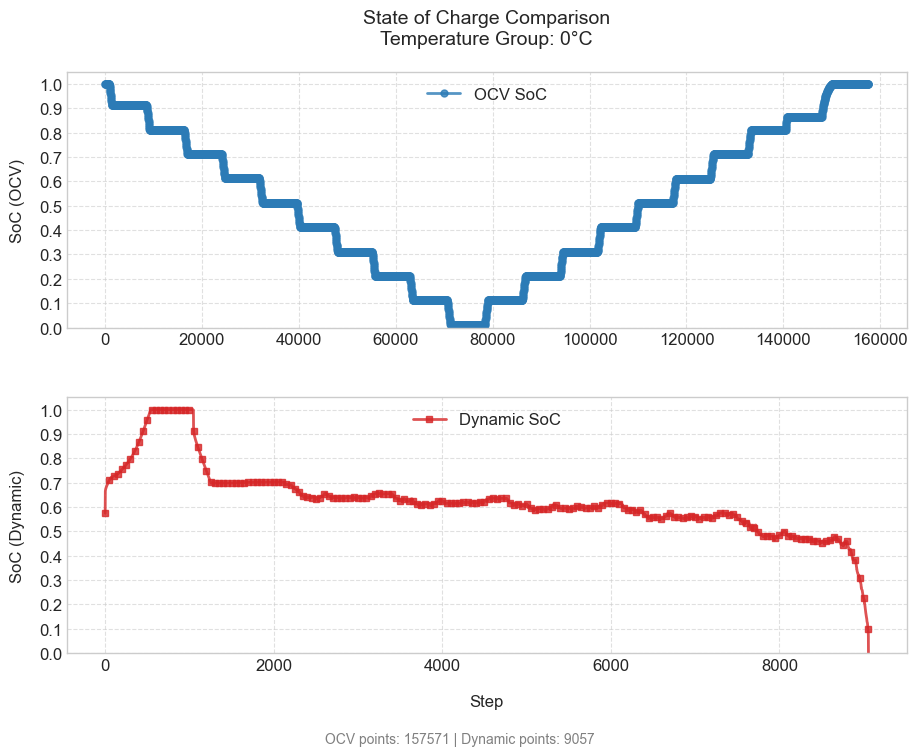

In [32]:
# Configure plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Prepare data
data1 = ocv_features_sp1["temp_0"]
x1 = data1.index
data2 = dynamic_features["fuds_50"]["temp_0"]
x2 = data2.index

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), dpi=100, sharex=False)

# -----------------------------------
# Top plot (OCV SoC)
# -----------------------------------
ax1.plot(
    x1,
    data1["SoC"],
    linewidth=2,
    color='#2c7bb6',
    marker='o',
    markersize=5,
    markevery=50,
    alpha=0.8,
    label='OCV SoC'
)

ax1.set_title('State of Charge Comparison\nTemperature Group: 0°C', pad=20)
ax1.set_ylabel('SoC (OCV)', labelpad=10)
ax1.set_ylim(0, 1.05)
ax1.set_yticks(np.arange(0, 1.1, 0.1))
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper center', framealpha=1)

# -----------------------------------
# Bottom plot (Dynamic SoC)
# -----------------------------------
ax2.plot(
    x2,
    data2["SoC"],
    linewidth=2,
    color='#d62728',  # Different color for contrast
    marker='s',
    markersize=5,
    markevery=50,
    alpha=0.8,
    label='Dynamic SoC'
)

ax2.set_xlabel('Step', labelpad=15)
ax2.set_ylabel('SoC (Dynamic)', labelpad=10)
ax2.set_ylim(0, 1.05)
ax2.set_yticks(np.arange(0, 1.1, 0.1))
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper center', framealpha=1)

# -----------------------------------
# Final adjustments
# -----------------------------------
plt.tight_layout(pad=3.0)  # Add padding between subplots

# Add common annotation
fig.text(0.5, 0.02, 
         f'OCV points: {len(data1)} | Dynamic points: {len(data2)}',
         ha='center',
         fontsize=10,
         color='gray')

plt.show()

### Generating the Target Variable

#### Nominal Values

##### Capacity
Extract the nominal capacity for each sample based on the maximum discharge capacity recorded during the initial test. From initial tests files.

* `nominal_capacity_sp1` for OCV test Sample1
* `nominal_capacity_sp2` for OCV test Sample2
* `nominal_capacity_dyn` for dynamic tests

In [33]:
# OCV Sample1 nominal_capacity
nominal_capacity_sp1 = ocv_initial["initial_sp1"]["Discharge_Capacity(Ah)"].max()
print(f"{nominal_capacity_sp1} Ah")

2.009444140560707 Ah


In [34]:
# OCV Sample2 nominal_capacity
nominal_capacity_sp2 = ocv_initial["initial_sp2"]["Discharge_Capacity(Ah)"].max()
print(f"{nominal_capacity_sp2} Ah")

2.000507188832521 Ah


In [35]:
# Dynamic nominal_capacity
nominal_capacity_dyn = dyn_initial["initial"]["Discharge_Capacity(Ah)"].max()
print(f"{nominal_capacity_dyn} Ah")

2.098344937765965 Ah


##### Internal Resistance
Extract the nominal internal resistance for each DataFrame. The value is estimated as the mean of the internal resistance measured during the initial test.

* `nominal_ir_sp1` for OCV test Sample1
* `nominal_ir_sp2` for OCV test Sample2
* `nominal_ir_dyn` for dynamic tests

In [36]:
ocv_ir_sp1_values = ocv_initial["initial_sp1"]["Internal_Resistance(Ohm)"].unique()
nominal_ir_sp1 = np.mean(ocv_ir_sp1_values[ocv_ir_sp1_values > 0])
print(f"{nominal_ir_sp1} Ohm")

0.11652602006991704 Ohm


In [37]:
ocv_ir_sp2_values = ocv_initial["initial_sp2"]["Internal_Resistance(Ohm)"].unique()
nominal_ir_sp2 = np.mean(ocv_ir_sp2_values[ocv_ir_sp2_values > 0])
print(f"{nominal_ir_sp2} Ohm")

0.07301342189311984 Ohm


In [38]:
dyn_ir_values = dyn_initial["initial"]["Internal_Resistance(Ohm)"].unique()
nominal_ir_dyn = np.mean(dyn_ir_values[dyn_ir_values > 0])
print(f"{nominal_ir_dyn} Ohm")

0.058727468053499855 Ohm


#### SoH by Capacity
Create three dictionaries to store SoH by capacity values:
* `soh_by_cap_ocv_sp1` for OCV Sample 1
* `soh_by_cap_ocv_sp2` for OCV Sample 2
* `soh_by_cap_dyn` nested dict, for dynamic load profiles

In the `calculate_soh_cap_ocv` function, SoH is computed as:

$$
\text{\textit{SoH}} = \frac{Q_{\text{discharge}}^{\text{max}}}{Q_{\text{nominal}}}
$$

Where:
- $Q_{\text{discharge}}^{\text{max}}$ = Maximum measured discharge capacity in ocv tests (Ah)
- $Q_{\text{nominal}}$ = nominal capacity from the initial tests (Ah)

In [39]:
# dictionary of soh by cap Series for ocv sp1
soh_by_cap_ocv_sp1 = process_dataframes(
    final_ocv_sp1,
    target.calculate_soh_cap_ocv,
    nominal_capacity=nominal_capacity_sp1,
)

In [40]:
# dictionary of soh by cap Series for ocv sp2
soh_by_cap_ocv_sp2 = process_dataframes(
    final_ocv_sp2,
    target.calculate_soh_cap_ocv,
    nominal_capacity=nominal_capacity_sp2,
)

The function `calculate_soh_cap_dyn` calculates the battery's state of health by comparing the maximum charge capacity and the capacity at the selected cycle step. First, the overall maximum charge (Q_ch_max) is determined, followed by the peak capacity at the specified step (Q_ch_step_max). The difference between them (ΔQ) is subtracted from the maximum discharge capacity (Q_dis_max), yielding the real available capacity taking into account the initial charge at the specified step in dynamic tests

In [41]:
# nested dictionary of soh by cap Series
soh_by_cap_dyn = {
    name: process_dataframes(
        dict_of_frames,
        target.calculate_soh_cap_dyn,
        step_index_value=3,
        nominal_capacity=nominal_capacity_dyn,
    )
    for name, dict_of_frames in final_dynamic_data.items()
}

#### SoH by Internal Resistance
Create three dictionaries to store SoH by ir values:
1. `soh_by_ir_ocv_sp1` for OCV Sample 1
2. `soh_by_ir_ocv_sp2` for OCV Sample 2
3. `soh_by_ir_dyn` nested dict, for dynamic load profiles

Estimates battery State of Health (SoH) based on an exponential model of internal resistance (IR) increase.\
In the `calculate_soh_ir` function, SoH is computed as:
$$
\textit{SoH} = e^{-\alpha \cdot \Delta R}, \quad \Delta R = \max(\text{IR} - R_{\text{nominal}}, 0)
$$  
Where:  
- $\Delta R$ = excess resistance above nominal (clipped to avoid negative values).  
- $\alpha$ = degradation coefficient, $\alpha$ = 0.5.  

In [42]:
# dictionary of soh by cap Series for ocv sp1
soh_by_ir_ocv_sp1 = process_dataframes(
    ocv_features_sp1, target.calculate_soh_ir, ir_nominal=nominal_ir_sp1
)

In [43]:
# dictionary of soh by cap Series for ocv sp2
soh_by_ir_ocv_sp2 = process_dataframes(
    ocv_features_sp2, target.calculate_soh_ir, ir_nominal=nominal_ir_sp2
)

In [44]:
# nested dictionary of soh by ir Series
soh_by_ir_dyn = {
    name: process_dataframes(
        dict_of_frames, target.calculate_soh_ir, ir_nominal=nominal_ir_dyn
    )
    for name, dict_of_frames in dynamic_features.items()
}

#### Target SoH Value
This code block calculates averaged State of Health (SoH) values by combining capacity-based and internal resistance-based measurements for different test conditions.

The final target SoH values for each test are contained in the dictionary `soh_target`:
1. `ocv_sp1` for OCV Sample 1
2. `ocv_sp2` for OCV Sample 2
3. `dyn` nested dict, for dynamic load profiles

The function `average_soh(cap_dict, ir_dict)` is used to compute average SoH values by mean.

Since the `soh_by_cap_dyn` and `soh_by_ir_dyn` dictionaries are nested, the `process_nested_dicts()` function provides a way to handle their merging while automatically managing key matching and error handling

In [45]:
# Final target SoH
soh_target = {
    "ocv_sp1": target.average_soh(soh_by_cap_ocv_sp1, soh_by_ir_ocv_sp1),
    "ocv_sp2": target.average_soh(soh_by_cap_ocv_sp2, soh_by_ir_ocv_sp2),
    "dyn": process_nested_dicts(soh_by_cap_dyn, soh_by_ir_dyn, target.average_soh),
}

## Data Preparation & Splitting

### Data Preparation

#### Merging features 

Merge features for each test.  
The output is a nested dictionary where each key is a test type and each value is a dictionary of DataFrames

In [46]:
# Merging features in a nested dictionary
Merged_features = {
    "ocv_sp1": ocv_features_sp1,
    "ocv_sp2": ocv_features_sp2,
    "dyn": dynamic_features,
}

#### Creating Final DataFrames with Target

Attach the target SoH variable after feature merging, resulting in a `final_features` dictionary containing complete DataFrames ready for filtering and transformation.\
**For ocv tests:**
```python
{'temp': merged_df }
```
**For dyn tests:**
```python
{'test_name': {'temp': merged_df}}

In [47]:
# Final DataFrames for each type of test
final_features = {
    "ocv_sp1": merge_dicts(Merged_features["ocv_sp1"], soh_target["ocv_sp1"]),
    "ocv_sp2": merge_dicts(Merged_features["ocv_sp2"], soh_target["ocv_sp2"]),
    "dyn": process_nested_dicts(Merged_features["dyn"], soh_target["dyn"], merge_dicts),
}

In [48]:
# Final dyn test DataFrame preview
final_features["dyn"]["dst_50"]["temp_0"].head()

,Current(A),dV/dt(V/s),dI/dt(A/s),power_avg(W),Voltage_Current_cov,energy_wh,is_discharging,weight_0,weight_25,weight_45,nearest_temp,IR(Ohm),SoC,SoC_variance,IR_change_rate,SoH
0,0.000000,NaN,NaN,NaN,NaN,0.000000,0,1.0,4.000000e-08,2.222222e-08,0,0.154043,0.568759,NaN,NaN,0.881627
1,0.999533,NaN,NaN,NaN,NaN,0.010035,1,1.0,4.000000e-08,2.222222e-08,0,0.154043,0.655282,NaN,NaN,0.881627
2,0.999533,NaN,NaN,NaN,NaN,0.020103,1,1.0,4.000000e-08,2.222222e-08,0,0.154043,0.659189,NaN,NaN,0.881627
3,0.999533,NaN,NaN,NaN,NaN,0.030184,1,1.0,4.000000e-08,2.222222e-08,0,0.154043,0.661952,NaN,NaN,0.881627
4,0.999713,NaN,NaN,NaN,NaN,0.040278,1,1.0,4.000000e-08,2.222222e-08,0,0.154043,0.664144,NaN,NaN,0.881627


#### Concatenating All Frames into a Unified Dataset

In [49]:
all_frames = []

# Add OCV data (ocv_sp1 and ocv_sp2)
for ocv_key in ["ocv_sp1", "ocv_sp2"]:
    if ocv_key in final_features:
        for temp, df in final_features[ocv_key].items():
            df = df.copy()
            df.insert(0, "test_name", ocv_key)
            all_frames.append(df)

# Add dynamic test data (unpacking nested dictionaries)
if "dyn" in final_features:
    for test_name, temp_dict in final_features["dyn"].items():
        for df in temp_dict.values():
            df = df.copy()
            df.insert(0, "test_name", test_name)
            all_frames.append(df)

# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(all_frames, axis=0, ignore_index=True)

In [50]:
# Combined df preview
combined_df.head()

# Optional: DataFrame info
# combined_df.info()

,test_name,Current(A),dV/dt(V/s),dI/dt(A/s),power_avg(W),Voltage_Current_cov,energy_wh,is_discharging,weight_0,weight_25,weight_45,nearest_temp,IR(Ohm),SoC,SoC_variance,IR_change_rate,SoH
0,ocv_sp1,0.0,NaN,NaN,NaN,NaN,0.0,0,1.0,4.000000e-08,2.222222e-08,0,0.114081,1.0,NaN,NaN,0.927596
1,ocv_sp1,0.0,NaN,NaN,NaN,NaN,0.0,0,1.0,4.000000e-08,2.222222e-08,0,0.114081,1.0,NaN,NaN,0.927596
2,ocv_sp1,0.0,NaN,NaN,NaN,NaN,0.0,0,1.0,4.000000e-08,2.222222e-08,0,0.114081,1.0,NaN,NaN,0.927596
3,ocv_sp1,0.0,NaN,NaN,NaN,NaN,0.0,0,1.0,4.000000e-08,2.222222e-08,0,0.114081,1.0,NaN,NaN,0.927596
4,ocv_sp1,0.0,NaN,NaN,NaN,NaN,0.0,0,1.0,4.000000e-08,2.222222e-08,0,0.114081,1.0,NaN,NaN,0.927596


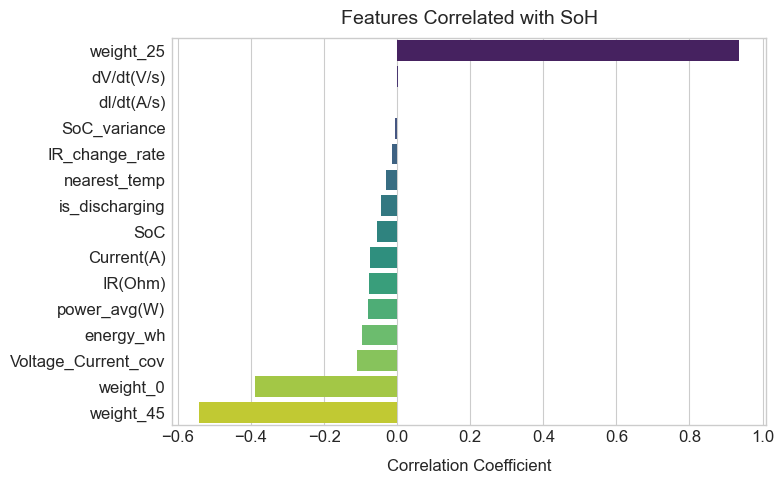

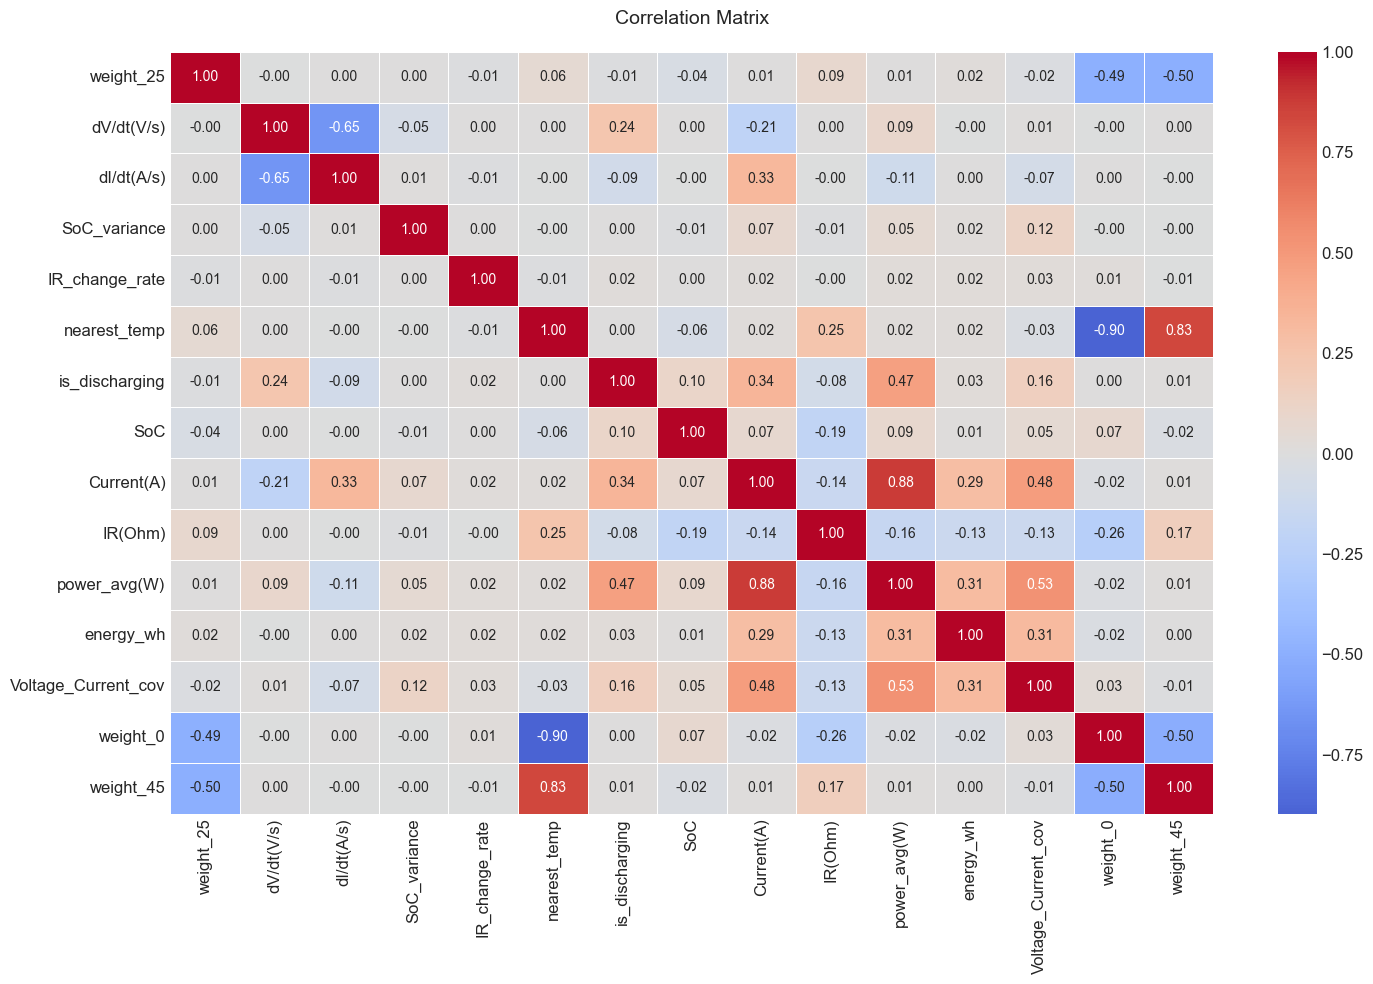


Feature correlations with SoH:
SoH                    1.000
weight_25              0.935
dV/dt(V/s)             0.001
dI/dt(A/s)            -0.000
SoC_variance          -0.005
IR_change_rate        -0.015
nearest_temp          -0.030
is_discharging        -0.045
SoC                   -0.055
Current(A)            -0.074
IR(Ohm)               -0.077
power_avg(W)          -0.079
energy_wh             -0.095
Voltage_Current_cov   -0.109
weight_0              -0.389
weight_45             -0.541


In [51]:
# Drop unnecessary column
df = combined_df.drop(columns=["test_name"])

# 1. Calculate correlations with target
target_col = "SoH"  # Target variable
correlations = df.corr()[target_col].sort_values(ascending=False)

# 2. Visualize correlations
plt.figure(figsize=(8, 5))  # Increased height for better readability
top_features = correlations.drop(target_col).head(20)

# Create visualization DataFrame
plot_df = pd.DataFrame(
    {"features": top_features.index, "correlation": top_features.values}
)

# Enhanced barplot visualization
ax = sns.barplot(
    data=plot_df,
    x="correlation",
    y="features",
    hue="features",
    palette="viridis",
    legend=False,
    dodge=False,  # Prevent spacing between bars
)

# Improve visualization
plt.title(f"Features Correlated with {target_col}", pad=10)
plt.xlabel("Correlation Coefficient", labelpad=10)
plt.ylabel("")
ax.tick_params(axis="y", which="major", pad=5)  # Add padding to y-axis ticks
plt.tight_layout()
plt.show()

# 3. Correlation matrix for features
top_corr_features = correlations.drop(target_col).head(20).index
corr_matrix = df[top_corr_features].corr()

plt.figure(figsize=(15, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 10},  # Adjust annotation size
)
plt.title("Correlation Matrix", pad=20)
plt.tight_layout()
plt.show()

# 4. Print correlation table with improved formatting
print(f"\nFeature correlations with {target_col}:")
print(correlations.to_string(float_format=lambda x: f"{x:.3f}").replace("NaN", " - "))

#### Postprocessing Cleaning 

Clean data: drop missing values, remove duplicates

In [52]:
# Remove rows with any missing or invalid values and drop test name column
combined_df_cleaned = combined_df.dropna().drop(columns=["test_name"])

# Remove full duplicates (rows where all values are identical)
final_cleaned_df = combined_df_cleaned.drop_duplicates().reset_index(drop=True)

# [Optional] Print before/after sizes
print(f"Original size: {combined_df.shape}")
print(f"Cleaned size: {final_cleaned_df.shape}")

Original size: (1132028, 17)
Cleaned size: (281986, 16)


In [53]:
# Final cleaned df preview
final_cleaned_df.head()

# Optional: DataFrame info
# final_cleaned_df.info()

,Current(A),dV/dt(V/s),dI/dt(A/s),power_avg(W),Voltage_Current_cov,energy_wh,is_discharging,weight_0,weight_25,weight_45,nearest_temp,IR(Ohm),SoC,SoC_variance,IR_change_rate,SoH
0,0.180465,0.000032,-0.004424,0.849417,0.004819,-0.038385,1,1.0,4.000000e-08,2.222222e-08,0,0.114081,1.0,0.0,0.0,0.927596
1,0.176868,0.000000,-0.004172,0.826833,0.004511,-0.036318,1,1.0,4.000000e-08,2.222222e-08,0,0.114081,1.0,0.0,0.0,0.927596
2,0.173272,0.000000,-0.003884,0.806364,0.004168,-0.034293,1,1.0,4.000000e-08,2.222222e-08,0,0.114081,1.0,0.0,0.0,0.927596
3,0.170035,0.000097,-0.003668,0.787587,0.003790,-0.032306,1,1.0,4.000000e-08,2.222222e-08,0,0.114081,1.0,0.0,0.0,0.927596
4,0.166798,0.000000,-0.003524,0.770034,0.003380,-0.030357,1,1.0,4.000000e-08,2.222222e-08,0,0.114081,1.0,0.0,0.0,0.927596


#### Data Aggregation

In [54]:
# List of aggregation functions for numeric features
agg_funcs = ['mean', 'std', 'min', 'max']

# Categorical feature to aggregate separately
categorical_feature = 'nearest_temp'
weights = ['weight_0', 'weight_25', 'weight_45']

# List of numeric features excluding temperature-related ones
numeric_features = [f for f in dyn_feature_extraction_functions.keys()
                    if f not in weights + [categorical_feature]]

df = final_cleaned_df

# Aggregate numeric features by SoH
agg_numeric = df.groupby('SoH')[numeric_features].agg(agg_funcs).reset_index()
# Flatten multi-index columns
agg_numeric.columns = ['SoH'] + [f'{col}_{stat}' for col, stat in agg_numeric.columns[1:]]

# Aggregate weight features (mean)
agg_weights = df.groupby('SoH')[weights].mean().reset_index()

# Aggregate categorical feature (mode)
agg_temp_mode = df.groupby('SoH')[categorical_feature].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
).reset_index().rename(columns={categorical_feature: 'nearest_temp_mode'})

# Merge all aggregated parts on SoH and drop NaNs
agg_result = agg_numeric.merge(agg_weights, on='SoH').merge(agg_temp_mode, on='SoH')
agg_result.dropna(inplace=True)

In [55]:
# Aggregated features preview and drop NaN
agg_result.head()

# Optional: Aggregated features info
# agg_result.info()

,SoH,Current(A)_mean,Current(A)_std,Current(A)_min,Current(A)_max,dV/dt(V/s)_mean,dV/dt(V/s)_std,dV/dt(V/s)_min,dV/dt(V/s)_max,dI/dt(A/s)_mean,...,SoC_variance_min,SoC_variance_max,IR_change_rate_mean,IR_change_rate_std,IR_change_rate_min,IR_change_rate_max,weight_0,weight_25,weight_45,nearest_temp_mode
0,0.868902,4.000303,0.000254,4.000124,4.000483,-0.024461,0.000183,-0.024590,-0.024331,0.000000,...,0.011007,0.012198,0.000020,0.000000,0.000020,0.000020,1.0,4.000000e-08,2.222222e-08,0
1,0.868917,3.591733,0.651240,2.531573,4.000303,-0.078442,0.048103,-0.133319,-0.017430,0.253336,...,0.004124,0.009776,0.000022,0.000013,0.000000,0.000039,1.0,4.000000e-08,2.222222e-08,0
3,0.868934,2.124262,0.784192,1.569755,2.678770,-0.101002,0.013402,-0.110478,-0.091525,0.193437,...,0.001804,0.002189,0.000040,0.000005,0.000037,0.000044,1.0,4.000000e-08,2.222222e-08,0
6,0.868954,0.860614,1.067051,0.106095,1.615133,0.044305,0.045566,0.012085,0.076525,0.053124,...,0.000424,0.000709,0.000037,0.000010,0.000030,0.000044,1.0,4.000000e-08,2.222222e-08,0
7,0.868960,0.655744,0.061203,0.612467,0.699021,0.070013,0.038991,0.042442,0.097584,-0.146381,...,0.000427,0.000540,0.000044,0.000011,0.000037,0.000052,1.0,4.000000e-08,2.222222e-08,0


### Data Splitting

#### Train-Test Split

In [56]:
# Separate features and target
X = agg_result.drop(
    columns=[
        "SoH",
    ]
)
y = agg_result["SoH"]

# Train-test split (80/20) with fixed seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=32
)

#### Data Distribution Analysis

Total samples: 16647


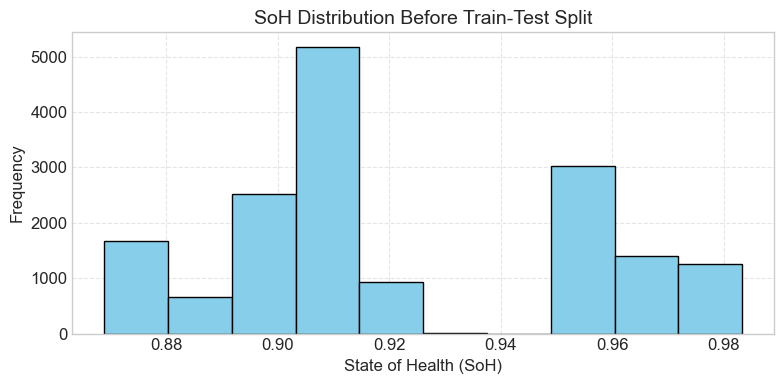

Training set size: 13317 samples
Test set size: 3330 samples


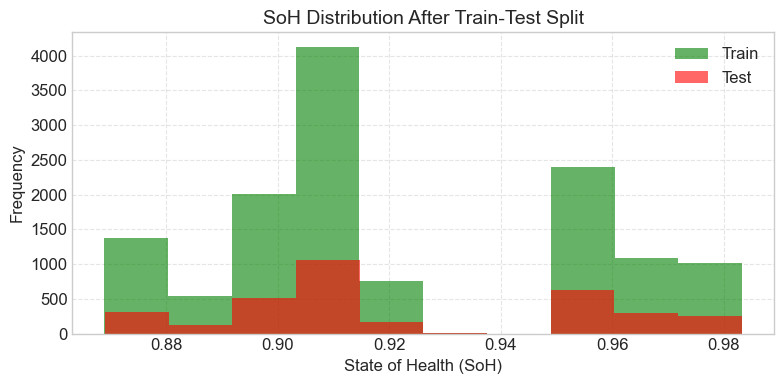

In [57]:
# Check feature/target dimensions
print(f"Total samples: {X.shape[0]}")
# print(f"Number of features: {X.shape[1]}")

# Visualize SoH distribution before the split
plt.figure(figsize=(8, 4))
plt.hist(y, bins=10, color="skyblue", edgecolor="black")
plt.title("SoH Distribution Before Train-Test Split")
plt.xlabel("State of Health (SoH)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Check resulting splits
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Visualize the target distribution in each set
plt.figure(figsize=(8, 4))
plt.hist(y_train, bins=10, alpha=0.6, label="Train", color="green")
plt.hist(y_test, bins=10, alpha=0.6, label="Test", color="red")
plt.title("SoH Distribution After Train-Test Split")
plt.xlabel("State of Health (SoH)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### (Optional) Data Balancing

In [58]:
# # Bins analysis
# bins = np.arange(0.85, 1.0, 0.01)

In [59]:
# agg_result['SoH_bins'] = pd.cut(agg_result['SoH'], bins=bins, right=False) 
# agg_result['SoH_bins'].value_counts().sort_index()

In [60]:
# from battery_soh_estimator.utils.balancer import balance_data

# # Applying data balancing function
# df_balanced = balance_data(
#     df=agg_result.copy(),  # Create copy of source data
#     n_synthetic=2000,      # Number of synthetic samples
#     target_col='SoH',      # Target variable
#     low_thresh=0.92,       # Lower bound of target SoH range
#     high_thresh=0.95,      # Upper bound of target SoH range
#     diversity_strength=0.5  # Diversity level (0-1)
# )

# # Checking results
# print(f"Original data size: {len(agg_result)}")
# print(f"Size after balancing: {len(df_balanced)}")
# print("\nSoH distribution after balancing:")
# print(df_balanced['SoH'].describe())

In [61]:
# df_balanced['SoH_bins'] = pd.cut(df_balanced['SoH'], bins=bins, right=False) 
# df_balanced['SoH_bins'].value_counts().sort_index()

In [62]:
# # Separate features and target
# X = df_balanced.drop(
#     columns=[
#         "SoH",
#         "SoH_bins"
#     ]
# )
# y = df_balanced["SoH"]

# # Train-test split (80/20) with fixed seed for reproducibility
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=32
# )

In [63]:
# # Check feature/target dimensions
# print(f"Total samples: {X.shape[0]}")
# # print(f"Number of features: {X.shape[1]}")

# # Visualize SoH distribution before the split
# plt.figure(figsize=(8, 4))
# plt.hist(y, bins=10, color="skyblue", edgecolor="black")
# plt.title("SoH Distribution Before Train-Test Split")
# plt.xticks(np.arange(0.85, 1.0, 0.05))
# plt.xlabel("State of Health (SoH)")
# plt.ylabel("Frequency")
# plt.grid(True, linestyle="--", alpha=0.5)
# plt.tight_layout()
# plt.show()

# # Check resulting splits
# print(f"Training set size: {X_train.shape[0]} samples")
# print(f"Test set size: {X_test.shape[0]} samples")

# # Visualize the target distribution in each set
# plt.figure(figsize=(8, 4))
# plt.hist(y_train, bins=10, alpha=0.2, label="Train", color="green")
# plt.hist(y_test, bins=10, alpha=0.6, label="Test", color="red")
# plt.xticks(np.arange(0.85, 1.0, 0.01))
# plt.title("SoH Distribution After Train-Test Split")
# plt.xlabel("State of Health (SoH)")
# plt.ylabel("Frequency")
# plt.legend()
# plt.grid(True, linestyle="--", alpha=0.5)
# plt.tight_layout()
# plt.show()

# Model Training

In [64]:
model = BatterySoHModel(
    model_params={
        "n_estimators": 300,
        "random_state": 33,
        "n_jobs": -1,
    },
)

Training a model on an already prepared samples with extracted features or loading already trained model 

In [65]:
# Training options
new_train = True
model_path = "../models/battery_model.pkl"

if os.path.exists(model_path) and not new_train:
    print("[INFO] Model file found. Loading...")
    model.load(model_path)
else:
    print("[INFO] Starting training...")
    model.fit(
        X_train, y_train, features_already_extracted=True
    )  # Fit the model on training data
    model.save(model_path)
    print("[INFO] Training completed. Model saved.")

    # Confirm model was trained
    print(f"Model trained: {model.is_trained}")

[INFO] Starting training...
[INFO] Model saved to ../models/battery_model.pkl
[INFO] Training completed. Model saved.
Model trained: True


Perform a visual check to ensure the model has learned the relationship adequately. A scatter plot of true vs. predicted SoH is plotted. Ideally, points should lie close to the red dashed identity line (y = x), indicating accurate predictions.

In [66]:
y_pred_train = model.predict(
    X_train,
    features_already_extracted=True,
    aggregate=True,
    monotonic=False,
)

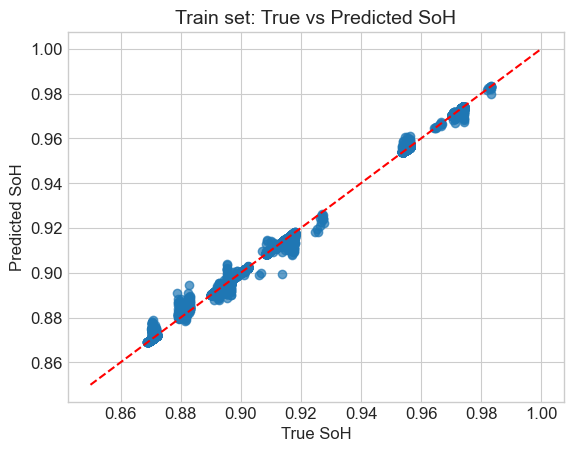

In [67]:
plt.scatter(y_train, y_pred_train, alpha=0.7)
plt.xlabel("True SoH")
plt.ylabel("Predicted SoH")
plt.title("Train set: True vs Predicted SoH")
plt.plot([0.85, 1.0], [0.85, 1.0], 'r--')  # Identity line
plt.grid(True)
plt.show()

Calculate the Mean Absolute Error (MAE) on the training set as a quick quantitative check. A low MAE here suggests the model has fitted well — but this must be compared against the test set to detect overfitting.

In [68]:
mae_train = mean_absolute_error(y_train, y_pred_train)
print(f"Train MAE: {mae_train:.9f}")

Train MAE: 0.000239957


# Evaluating

Evaluate its performance on the unseen test set to assess generalization. This step is crucial to understand if the model overfits the training data or can make accurate predictions on new inputs.

In [69]:
y_pred_test = model.predict(
    X_test,
    features_already_extracted=True,
    aggregate=True,
    monotonic=False,
)

Visualize the predicted vs. true SoH values for the test data. Ideally, points should align closely along the identity line (y = x). Any systematic deviation from this line may indicate underfitting, bias, or model drift.

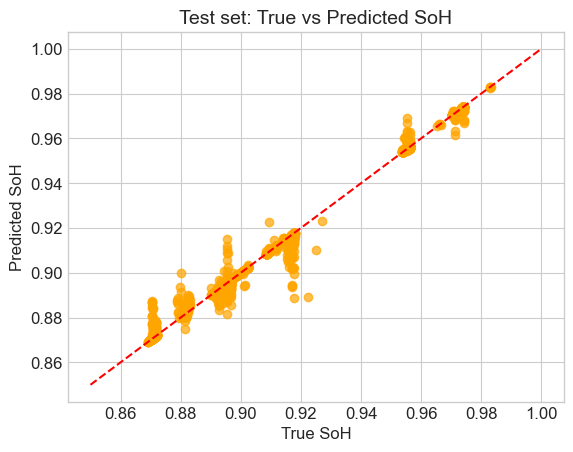

In [70]:
plt.scatter(y_test, y_pred_test, alpha=0.7, color='orange')
plt.xlabel("True SoH")
plt.ylabel("Predicted SoH")
plt.title("Test set: True vs Predicted SoH")
plt.plot([0.85, 1.0], [0.85, 1.0], 'r--')  # Identity line
plt.grid(True)
plt.show()

Compute the MAE on the test set, which serves as the main evaluation metric. Comparing this value with the training MAE helps assess model generalization. A large gap usually indicates overfitting.

In [71]:
mae_test = mean_absolute_error(y_test, y_pred_test)
print(f"Test MAE: {mae_test:.9f}")

Test MAE: 0.000620604


real-time data evaluation

In [72]:
data = pd.read_excel("../tests/Experimental_data_aged_cell.xlsx")
df = pd.DataFrame(data)

In [73]:
X = df.dropna()

In [74]:
model.reset_state()
y_pred_real = model.predict(
    X,
    features_already_extracted=False,
    aggregate=True,
    monotonic=True,
    chunk_size=1000,
)

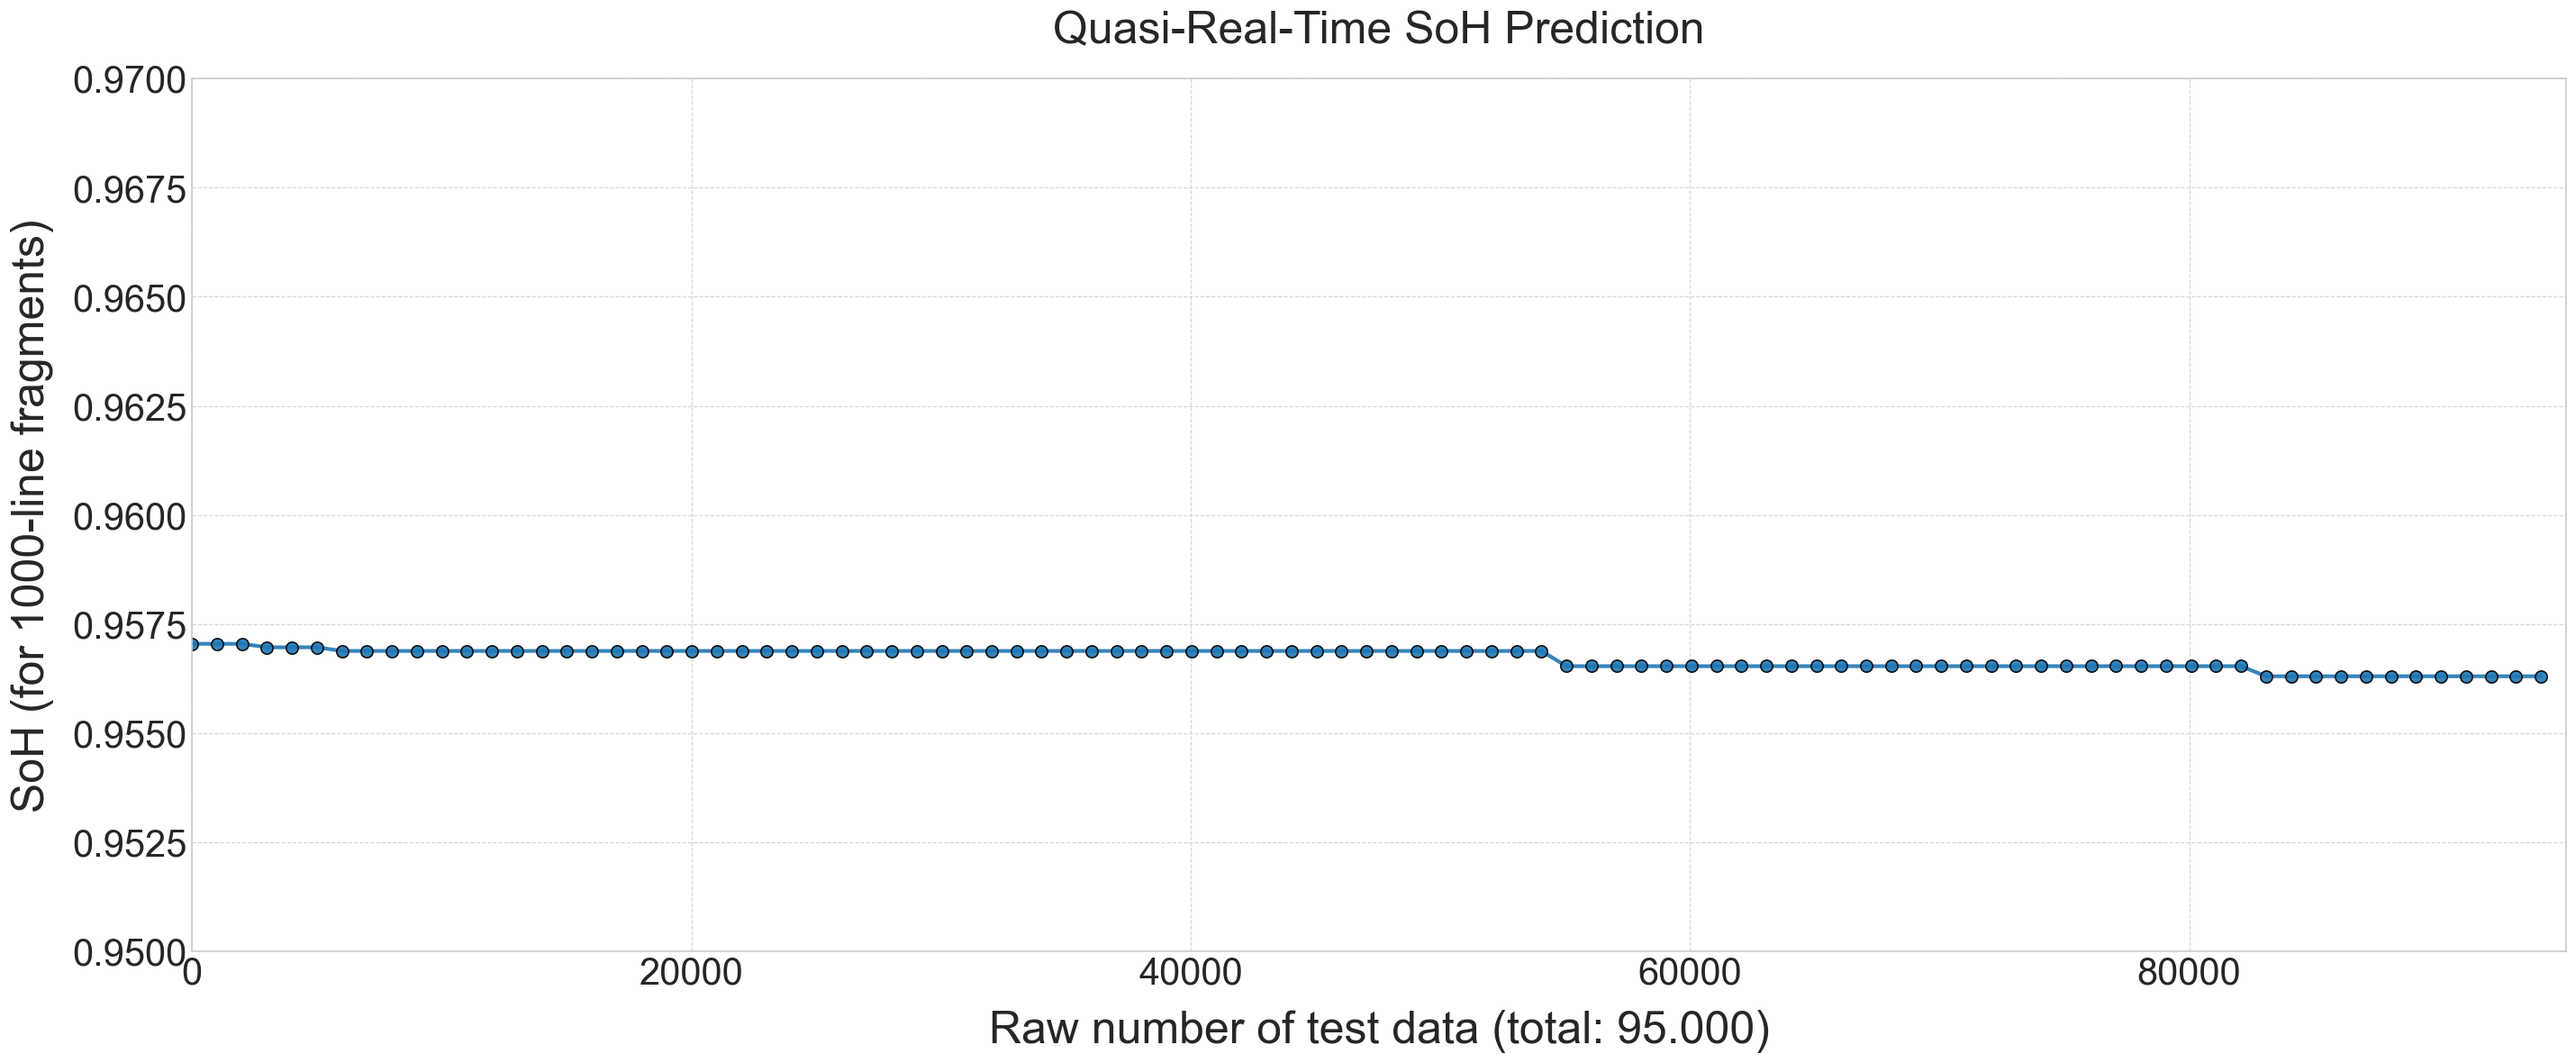

In [75]:
# Data parameters
total_rows = len(X)
chunk_size = 1000
n_chunks = total_rows // chunk_size

# Create array for X-axis (1 point per chunk)
x_values = np.linspace(0, total_rows, num=n_chunks, endpoint=False)

# Style configuration with increased font sizes
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(24, 10), dpi=120)

# Plot construction with enhanced visual elements
plt.plot(x_values, y_pred_real,
         linewidth=2.5,
         alpha=0.9,
         marker='o',
         markersize=8,
         markeredgecolor='black',
    )

# Axis configuration with expanded ranges
plt.xlim(0, total_rows)
plt.ylim([0.95, 0.97])

plt.tick_params(axis='both', which='major', labelsize=25)

# Labels and grid with larger fonts
plt.xlabel("Raw number of test data (total: 95.000)",
           fontsize=30,
           labelpad=12)
plt.ylabel("SoH (for 1000-line fragments)",
           fontsize=30,
           labelpad=12)
plt.title("Quasi-Real-Time SoH Prediction",
          fontsize=30,
          pad=24)

plt.grid(True, which='both',
         linestyle='--',
         linewidth=0.7,
         alpha=0.8)

plt.tight_layout()
plt.show()